In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Интегральные индексы

сделать индекс для оценки температуры - где есть минимум, максимум, оптимум.
нормализовать

In [ ]:
# tresholds = -5, 40
temp_thresholds = [-5, 40]

In [ ]:
def temperature_range(temp):
    if np.min(temp) < 0:
        return np.abs(np.min(temp)) + np.max(temp)
    else: 
        return np.max(temp) - np.min(temp)
    
temperature_range = temperature_range(temp_thresholds)
print(temperature_range)
print(temperature_range/2)

45
22.5


In [ ]:
# оптимум бует посреди границ
temp_optimum = temperature_range / 2.0 + np.min(temp_thresholds)
print(temp_optimum)

17.5


In [ ]:
# функция дает значения чем ближе к оптимуму тем лучше (за границами все к нулю)
def temperature_index(value, optimum):
    if value < np.min(temp_thresholds):
        return 0
    if value > np.max(temp_thresholds):
        return 0
    else:
        if value < 0:
            a = np.abs(np.min(temp_thresholds) - value)
            optimum_l = optimum + np.abs(np.min(temp_thresholds))
                
            if a < optimum_l:
                return 1 - (optimum_l-a) / optimum_l
            if a > optimum_l:
                return 1 - (a - optimum_l) / optimum_l
            if a == optimum_l:
                return 1
        
        if value > 0:
            a = np.abs(np.min(temp_thresholds)) + value
            optimum_l = optimum + np.abs(np.min(temp_thresholds))           
           # optimum =  np.max(temp_thresholds) - optimum 
            if a < optimum_l:
                return 1 - (optimum_l-a) / optimum_l
            if a > optimum_l:
                return 1 - np.abs(optimum_l - a) / optimum_l
            if a == optimum_l:
                return 1



<Axes: >

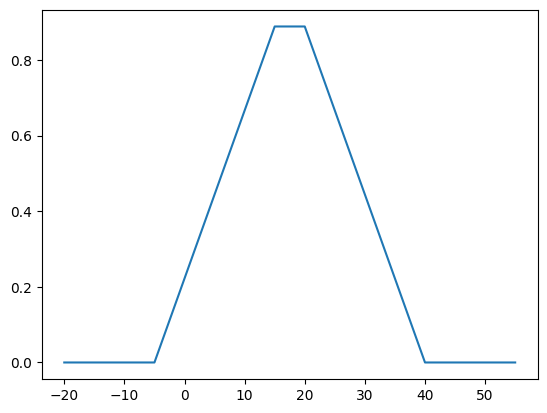

In [ ]:
# пример графика с таким индексом
temp_g_range = range(-20, 60, 5)
temp_g_list = []
for i in temp_g_range:
    temp_g_list.append(temperature_index(i, temp_optimum))

sns.lineplot(x=temp_g_range, y=temp_g_list)

индекс про сон - также как с температурой


In [ ]:
# тут тоже оптимум будет в середине
sleep_thresholds = [3, 11]
sleep_range = np.max(sleep_thresholds) - np.min(sleep_thresholds)
print(sleep_range)
sleep_optimum = (sleep_range / 2.0) + np.min(sleep_thresholds) 
print(sleep_range, sleep_optimum)

8
8 7.0


In [ ]:
def sleep_index(value, sleep_optimum):
    if value < np.min(sleep_thresholds):
        return 0
    if value > np.max(sleep_thresholds):
        return 0
    else:       
        if value < sleep_optimum:
            return 1 - ((sleep_optimum - value) / sleep_optimum)
        if value > sleep_optimum:
            return 1 - ((np.abs(sleep_optimum - value)) / sleep_optimum)
        if value == sleep_optimum:
            return 1


<Axes: >

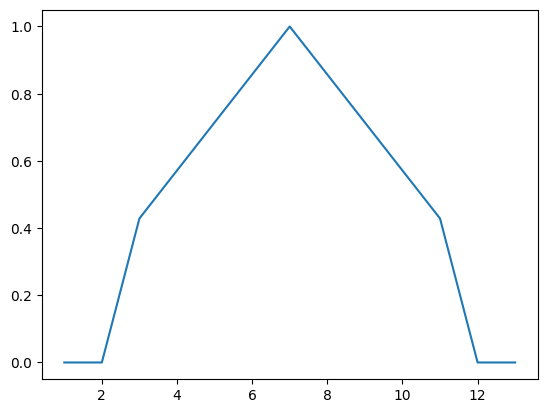

In [ ]:
sleep_g_range = range(1, 14, 1)
sleep_g_list = []
for i in sleep_g_range:
    sleep_g_list.append(sleep_index(i, sleep_optimum))
sns.lineplot(x=sleep_g_range, y= sleep_g_list)

In [ ]:

# индекс с усталостью тут просто разворот в пределах от нуля до единицы (если усталость больше 10 то индекс в ноль)

tired_index = lambda x: 1 - (x / 10) if x < 10 else 0

<Axes: >

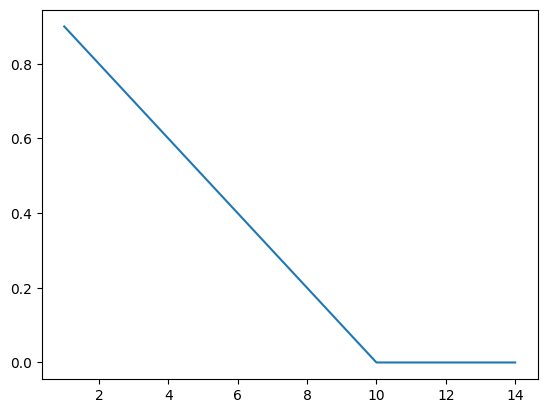

In [ ]:
tired_g_range = range(1, 15, 1)
tired_g_list = []
for i in tired_g_range:
    tired_g_list.append(tired_index(i))
sns.lineplot(x=tired_g_range, y= tired_g_list)

In [ ]:
# здесь три параметра: усталость, температура и сон
size=100
# temp_list = np.random.uniform(low=-15, high=45, size=60)
temp_list = np.random.normal(loc=12.0, scale=10.0, size=size)  # температура распределена нормально нижняя планка выходит за границы порогов [-5, 40]
sleep_list = np.random.uniform(low=2, high=12, size=size)  # сон равномерно от 2 до 12  (выходит за границу порога с обоих сторон) [3, 11]
# tired_list = np.random.randint(low=0, high=10, size=60)
tired_list = np.random.default_rng().exponential(scale=2.3, size=size)  # усталость экспоненциальна (в основном не человек бодр) иногда выходит за порог сверху   
print('Температура')
print(np.min(temp_list), np.max(temp_list), np.mean(temp_list), np.median(temp_list))
print('Усталость')
print(np.min(tired_list), np.max(tired_list), np.mean(tired_list), np.median(tired_list))
print('Сон')
print(np.min(sleep_list), np.max(sleep_list), np.mean(sleep_list), np.median(sleep_list))

days = pd.DataFrame({'sleep': sleep_list, 'temperature': temp_list, 'tired': tired_list})
days.head()

Температура
-13.589554017823968 43.2607545593835 13.238338264272643 12.522176703327808
Усталость
0.0310573822753446 7.9226579111158495 2.2661827518482536 1.5610902488378984
Сон
2.177768846310291 11.96244623252822 7.578797832453504 8.003020400670358


,sleep,temperature,tired
0,10.001989,12.564984,2.708025
1,7.769181,0.514828,4.899422
2,8.188053,6.476794,0.369897
3,5.777338,-0.552024,2.260162
4,4.170831,7.975521,0.237640


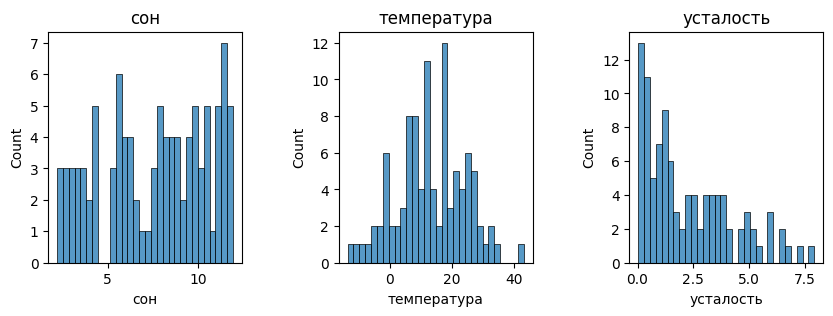

In [ ]:
plt.figure(figsize=(10, 3))       

plt.subplot(1, 3, 1)                            
sns.histplot(data=days['sleep'] , bins=30)
plt.xlabel('сон', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('сон')


plt.subplot(1, 3, 2)
sns.histplot(data=days['temperature'] , bins=30)
plt.xlabel('температура', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('температура')


plt.subplot(1, 3, 3)
sns.histplot(data=days['tired'] , bins=30)
plt.xlabel('усталость', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('усталость')

plt.subplots_adjust(hspace = 0.5) # увеличил расстояние между графиками
plt.subplots_adjust(wspace = 0.5) # увеличил расстояние между графиками
plt.show()

In [ ]:
# заведение индексов в таблицу

In [ ]:
def sleep_row(row):
    return sleep_index(row, sleep_optimum)
def temp_row(row):
    return temperature_index(row, temp_optimum)


In [ ]:
days['sleep_ind'] = days['sleep'].apply(sleep_row)
days['temperature_ind'] = days['temperature'].apply(temp_row)
days['tired_ind'] = days['tired'].apply(tired_index)

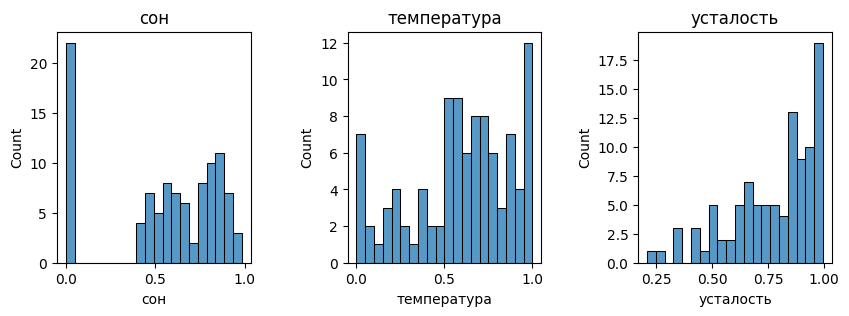

In [ ]:
plt.figure(figsize=(10, 3))       

plt.subplot(1, 3, 1)                            
sns.histplot(data=days['sleep_ind'] , bins=20)
plt.xlabel('сон', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('сон')


plt.subplot(1, 3, 2)
sns.histplot(data=days['temperature_ind'] , bins=20)
plt.xlabel('температура', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('температура')


plt.subplot(1, 3, 3)
sns.histplot(data=days['tired_ind'] , bins=20)
plt.xlabel('усталость', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('усталость')

plt.subplots_adjust(hspace = 0.5) # увеличил расстояние между графиками
plt.subplots_adjust(wspace = 0.5) # увеличил расстояние между графиками
plt.show()

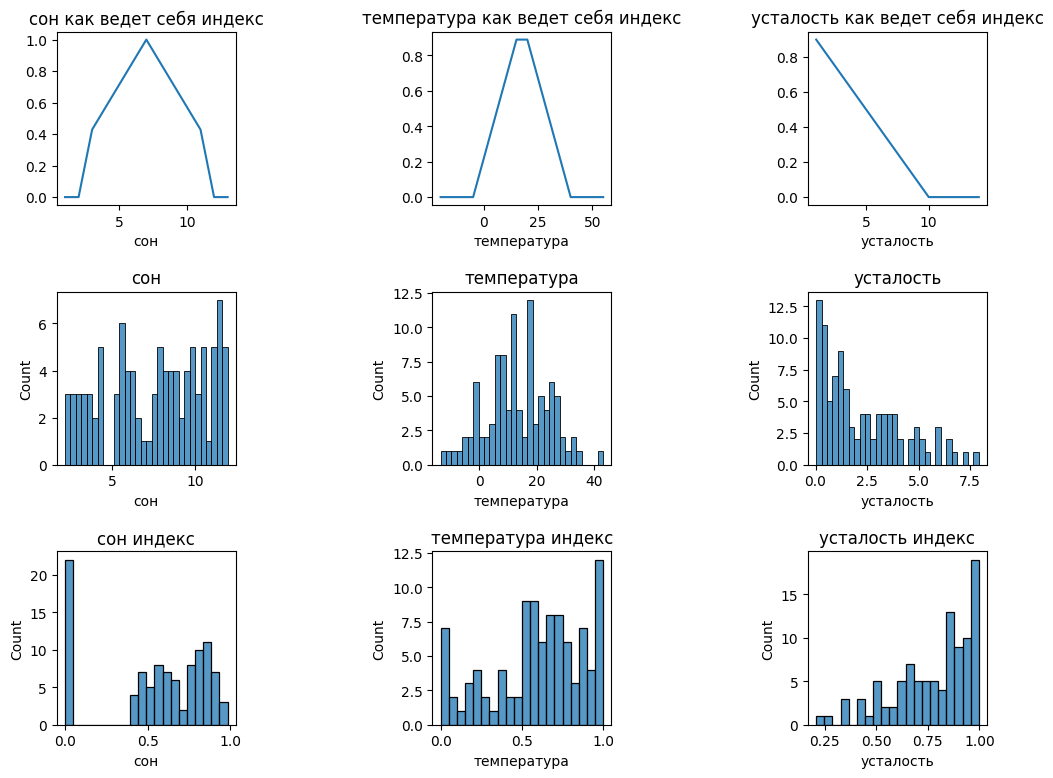

In [ ]:
plt.figure(figsize=(12, 9))       

plt.subplot(3, 3, 1)                            
sns.lineplot(x=sleep_g_range, y= sleep_g_list)
plt.xlabel('сон', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('сон как ведет себя индекс')


plt.subplot(3, 3, 2)
sns.lineplot(x=temp_g_range, y=temp_g_list)
plt.xlabel('температура', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('температура как ведет себя индекс')


plt.subplot(3, 3, 3)
sns.lineplot(x=tired_g_range, y= tired_g_list)
plt.xlabel('усталость', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('усталость как ведет себя индекс')


plt.subplot(3, 3, 4)                            
sns.histplot(data=days['sleep'] , bins=30)
plt.xlabel('сон', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('сон')


plt.subplot(3, 3, 5)
sns.histplot(data=days['temperature'] , bins=30)
plt.xlabel('температура', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('температура')


plt.subplot(3, 3, 6)
sns.histplot(data=days['tired'] , bins=30)
plt.xlabel('усталость', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('усталость')

plt.subplot(3, 3, 7)                            
sns.histplot(data=days['sleep_ind'] , bins=20)
plt.xlabel('сон', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('сон индекс')


plt.subplot(3, 3, 8)
sns.histplot(data=days['temperature_ind'] , bins=20)
plt.xlabel('температура', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('температура индекс')


plt.subplot(3, 3, 9)
sns.histplot(data=days['tired_ind'] , bins=20)
plt.xlabel('усталость', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('усталость индекс')

plt.subplots_adjust(hspace = 0.5) # увеличил расстояние между графиками
plt.subplots_adjust(wspace = 1.1) # увеличил расстояние между графиками
plt.show()

<Axes: xlabel='index_how', ylabel='Count'>

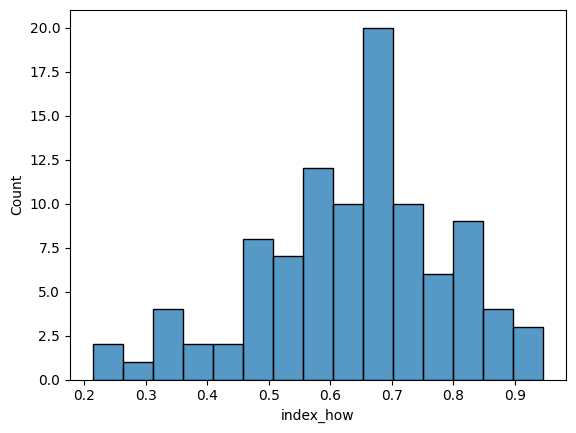

In [ ]:
# и совсем "интегральный индекс" коэфициенты для регулировки важности других вкладывающих в него
coefs = [10, 10, 10]
def united_index(data):
    return (coefs[0] * data['sleep_ind'] + coefs[1] * data['temperature_ind'] + coefs[2] * data['tired_ind']) / np.sum(coefs)
days['index_how'] = days.apply(united_index, axis=1)


sns.histplot(data=days['index_how'] , bins=15)

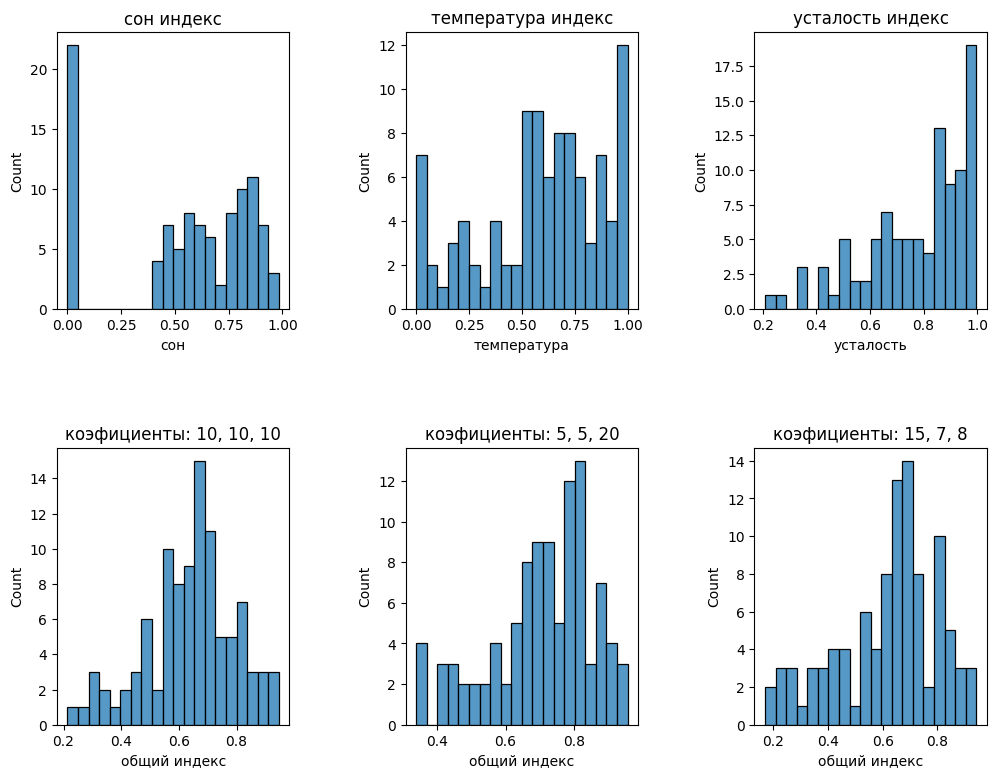

In [ ]:
plt.figure(figsize=(12, 9))       

plt.subplot(2, 3, 1)                            
sns.histplot(data=days['sleep_ind'] , bins=20)
plt.xlabel('сон', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('сон индекс')


plt.subplot(2, 3, 2)
sns.histplot(data=days['temperature_ind'] , bins=20)
plt.xlabel('температура', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('температура индекс')


plt.subplot(2, 3, 3)
sns.histplot(data=days['tired_ind'] , bins=20)
plt.xlabel('усталость', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('усталость индекс')

plt.subplot(2, 3, 4) 
coefs = [10, 10, 10]
def united_index(data):
    return (coefs[0] * data['sleep_ind'] + coefs[1] * data['temperature_ind'] + coefs[2] * data['tired_ind']) / np.sum(coefs)
days['index_how'] = days.apply(united_index, axis=1)
sns.histplot(data=days['index_how'] , bins=20)
plt.xlabel('общий индекс', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('коэфициенты: 10, 10, 10')

plt.subplot(2, 3, 5) 
coefs = [5, 5, 20]
def united_index(data):
    return (coefs[0] * data['sleep_ind'] + coefs[1] * data['temperature_ind'] + coefs[2] * data['tired_ind']) / np.sum(coefs)
days['index_how'] = days.apply(united_index, axis=1)
sns.histplot(data=days['index_how'] , bins=20)
plt.xlabel('общий индекс', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('коэфициенты: 5, 5, 20')

plt.subplot(2, 3, 6) 
coefs = [15, 7, 8]
def united_index(data):
    return (coefs[0] * data['sleep_ind'] + coefs[1] * data['temperature_ind'] + coefs[2] * data['tired_ind']) / np.sum(coefs)
days['index_how'] = days.apply(united_index, axis=1)
sns.histplot(data=days['index_how'] , bins=20)
plt.xlabel('общий индекс', fontsize=10)
plt.xticks(fontsize = 10, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.title('коэфициенты: 15, 7, 8')




plt.subplots_adjust(hspace = 0.5) # увеличил расстояние между графиками
plt.subplots_adjust(wspace = 0.5) # увеличил расстояние между графиками
plt.show()

<Axes: xlabel='index_how', ylabel='Count'>

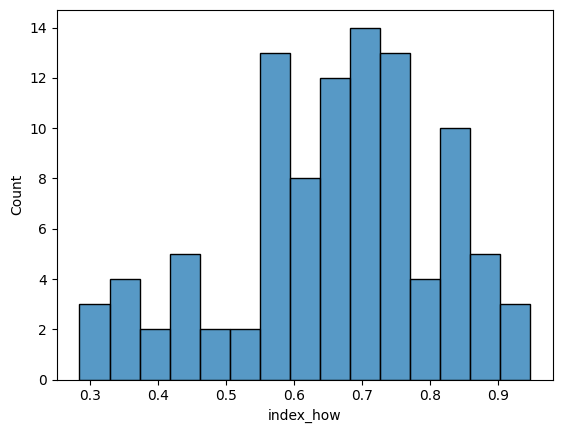

In [ ]:
# и совсем "интегральный индекс" коэфициенты для регулировки важности других вкладывающих в него
coefs = [15, 10, 20]
def united_index(data):
    return (coefs[0] * data['sleep_ind'] + coefs[1] * data['temperature_ind'] + coefs[2] * data['tired_ind']) / np.sum(coefs)
days['index_how'] = days.apply(united_index, axis=1)


sns.histplot(data=days['index_how'] , bins=15)

<Axes: >

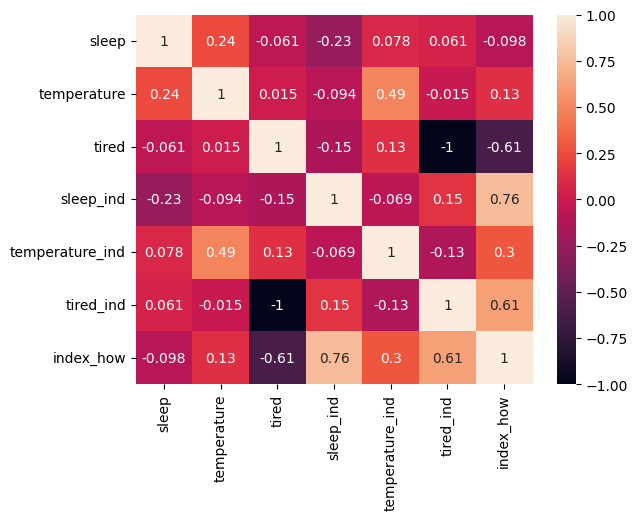

In [ ]:
sns.heatmap(days.corr(), annot=True)

In [ ]:
fig = px.scatter_3d(days, x='temperature', y='sleep', z='tired',
              color='index_how')
fig.show()
fig.write_html("C:/Users/v.kozlovskiy/Desktop/_data_benthos_presentation/3d_graph_param.html")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
fig = px.scatter_3d(days, x='temperature_ind', y='sleep_ind', z='tired_ind',
              color='index_how')
fig.show()
fig.write_html("C:/Users/v.kozlovskiy/Desktop/_data_benthos_presentation/3d_graph_ind.html")